# Problema 33 — Análisis de efectividad de campaña publicitaria

**Fuente pública:** https://github.com/justmarkham/scikit-learn-videos/blob/master/data/Advertising.csv  

El dataset contiene **200 observaciones** de mercados reales donde se midió la inversión publicitaria en tres canales (TV, Radio, Diario) y las ventas resultantes, todas en **miles de dólares (USD)**.

---

## 0. Instalación e importación de librerías

In [22]:
# Instalación (solo si es necesario)
# !pip install pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
COLORS = ['#3266AD', '#D85A30', '#1D9E75', '#F5A623', '#9B59B6']


---
## 1. Recolección de datos

**Paso 1 del análisis:** carga del dataset real desde GitHub (ISLR Advertising Dataset).

Las variables son:
- **TV**: presupuesto invertido en publicidad televisiva (miles USD)
- **Radio**: presupuesto invertido en publicidad radial (miles USD)  
- **Newspaper**: presupuesto invertido en publicidad impresa (miles USD)
- **Sales**: ventas del producto resultantes (miles USD) — variable objetivo

In [23]:
url = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"
df = pd.read_csv(url, index_col=0)
print(f'✓ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

✓ Dataset cargado: 200 filas, 4 columnas


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


---
## 2. Análisis Exploratorio de Datos (EDA)

In [24]:
# Estadísticas descriptivas completas
desc = df.describe().round(2)
print('ESTADÍSTICAS DESCRIPTIVAS (en miles de USD)')
print('='*55)
print(desc)
print()

# Medidas por variable
print(f'{"Variable":<12} {"Media":>8} {"Varianza":>10} {"Desvío":>8} {"Mín":>8} {"Máx":>8}')
print('-'*58)
for col in df.columns:
    print(f'{col:<12} {df[col].mean():>8.2f} {df[col].var():>10.2f} {df[col].std():>8.2f} {df[col].min():>8.1f} {df[col].max():>8.1f}')

ESTADÍSTICAS DESCRIPTIVAS (en miles de USD)
           TV   Radio  Newspaper   Sales
count  200.00  200.00     200.00  200.00
mean   147.04   23.26      30.55   14.02
std     85.85   14.85      21.78    5.22
min      0.70    0.00       0.30    1.60
25%     74.38    9.98      12.75   10.38
50%    149.75   22.90      25.75   12.90
75%    218.82   36.52      45.10   17.40
max    296.40   49.60     114.00   27.00

Variable        Media   Varianza   Desvío      Mín      Máx
----------------------------------------------------------
TV             147.04    7370.95    85.85      0.7    296.4
Radio           23.26     220.43    14.85      0.0     49.6
Newspaper       30.55     474.31    21.78      0.3    114.0
Sales           14.02      27.22     5.22      1.6     27.0


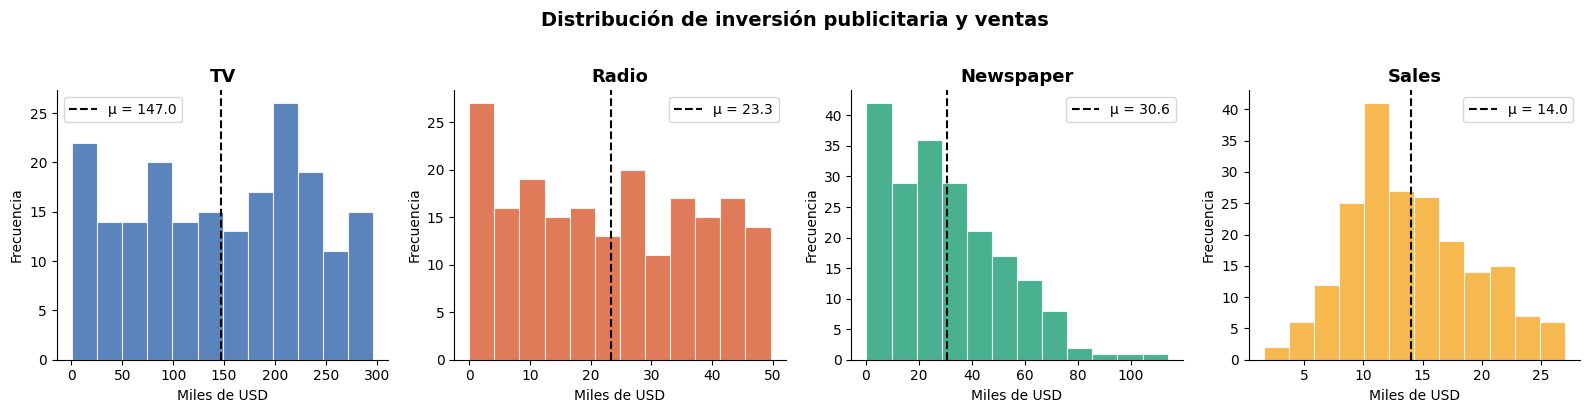

In [25]:
# Distribución de cada variable
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['TV', 'Radio', 'Newspaper', 'Sales']
colors = ['#3266AD', '#D85A30', '#1D9E75', '#F5A623', '#9B59B6']

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[i].hist(df[col], bins=12, color=color, alpha=0.8, edgecolor='white', linewidth=0.8)
    axes[i].axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'μ = {df[col].mean():.1f}')
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Miles de USD')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=10)

plt.suptitle('Distribución de inversión publicitaria y ventas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Función Masa de Probabilidad (FMP) de las Ventas

Sea **X** = ventas (en miles de USD) de un mercado seleccionado al azar.  
La FMP asigna una probabilidad a cada intervalo de ventas posible.

$$p(x) = \frac{\text{frecuencia del intervalo}}{n}$$

In [26]:
# FMP de ventas por intervalos
bins   = [0, 5, 10, 15, 20, 25, 30]
labels = ['0–4,9', '5–9,9', '10–14,9', '15–19,9', '20–24,9', '25+']

df['Sales_rango'] = pd.cut(df['Sales'], bins=bins, labels=labels, right=False)
freq = df['Sales_rango'].value_counts(sort=False)
n = len(df)
px   = freq / n
Fx   = px.cumsum()

fmp_df = pd.DataFrame({
    'Intervalo (x)': labels,
    'Frecuencia': freq.values,
    'p(x)': px.values.round(4),
    'F(x) = P(X ≤ x)': Fx.values.round(4)
})

print('FUNCIÓN MASA DE PROBABILIDAD — Ventas (miles USD)')
print('='*58)
print(fmp_df.to_string(index=False))
print(f"{'TOTAL':<20} {n:<12} {px.sum():.4f}")
print()
print(f'✓ Verificación: Σ p(x) = {px.sum():.4f} ← debe ser 1,000')

FUNCIÓN MASA DE PROBABILIDAD — Ventas (miles USD)
Intervalo (x)  Frecuencia  p(x)  F(x) = P(X ≤ x)
        0–4,9           3 0.015            0.015
        5–9,9          42 0.210            0.225
      10–14,9          78 0.390            0.615
      15–19,9          46 0.230            0.845
      20–24,9          25 0.125            0.970
          25+           6 0.030            1.000
TOTAL                200          1.0000

✓ Verificación: Σ p(x) = 1.0000 ← debe ser 1,000


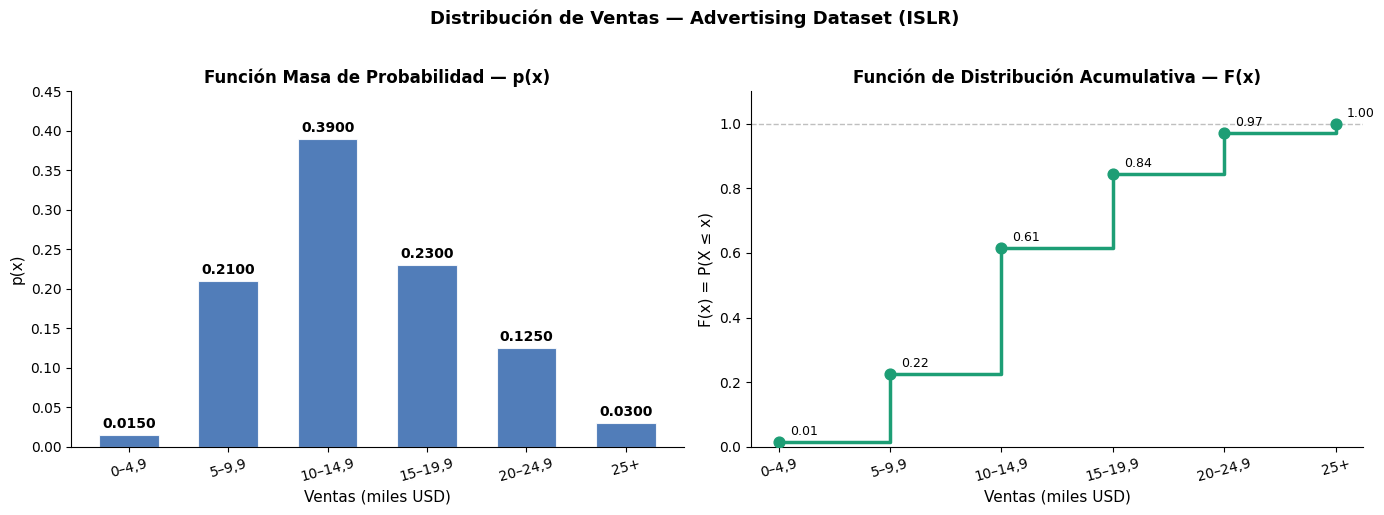

In [27]:
# Gráficos FMP y FDA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma FMP
bars = ax1.bar(labels, px.values, color='#3266AD', alpha=0.85, edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, px.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Función Masa de Probabilidad — p(x)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Ventas (miles USD)', fontsize=11)
ax1.set_ylabel('p(x)', fontsize=11)
ax1.set_ylim(0, 0.45)
ax1.tick_params(axis='x', rotation=15)

# FDA
ax2.step(range(len(labels)), Fx.values, color='#1D9E75', linewidth=2.5, where='post')
ax2.scatter(range(len(labels)), Fx.values, color='#1D9E75', s=60, zorder=5)
for i, (val, lbl) in enumerate(zip(Fx.values, labels)):
    ax2.annotate(f'{val:.2f}', (i, val), textcoords='offset points', xytext=(8, 5), fontsize=9)
ax2.axhline(1, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=15)
ax2.set_title('Función de Distribución Acumulativa — F(x)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Ventas (miles USD)', fontsize=11)
ax2.set_ylabel('F(x) = P(X ≤ x)', fontsize=11)
ax2.set_ylim(0, 1.1)

plt.suptitle('Distribución de Ventas — Advertising Dataset (ISLR)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Valor Esperado, Varianza y Desvío Estándar

$$E[X] = \mu = \sum x_i \cdot p(x_i) \qquad V(X) = \sigma^2 = \sum (x_i - \mu)^2 \cdot p(x_i) \qquad \sigma = \sqrt{V(X)}$$

In [28]:
# Puntos medios de cada intervalo para calcular E[X]
midpoints = [2.5, 7.5, 12.5, 17.5, 22.5, 27.5]
px_vals   = px.values

# Valor esperado
mu = sum(m * p for m, p in zip(midpoints, px_vals))

# Varianza
var = sum((m - mu)**2 * p for m, p in zip(midpoints, px_vals))

# Desvío estándar
sigma = var ** 0.5

# Tabla de cálculo
print('TABLA DE CÁLCULO — Valor Esperado y Varianza')
print('='*70)
print(f'{"Intervalo":<12} {"Punto medio":>12} {"p(x)":>8} {"x·p(x)":>10} {"(x-μ)²":>10} {"(x-μ)²·p(x)":>14}')
print('-'*70)
for lbl, m, p in zip(labels, midpoints, px_vals):
    xp    = m * p
    diff2 = (m - mu)**2
    dp    = diff2 * p
    print(f'{lbl:<12} {m:>12.1f} {p:>8.4f} {xp:>10.4f} {diff2:>10.4f} {dp:>14.4f}')
print('-'*70)
print(f'{"TOTAL":<12} {"":>12} {sum(px_vals):>8.4f} {mu:>10.4f} {"":>10} {var:>14.4f}')

print()
print('RESULTADOS:')
print(f'  E[X] = μ  = {mu:.4f} miles de USD  →  {mu*1000:.0f} USD en ventas promedio')
print(f'  V(X) = σ² = {var:.4f}')
print(f'  σ         = {sigma:.4f} miles de USD  →  ±{sigma*1000:.0f} USD de variación típica')

# Verificación con datos reales
print(f'\n  Verificación con datos reales:')
print(f'  Media real = {df["Sales"].mean():.4f}  |  Std real = {df["Sales"].std():.4f}')

TABLA DE CÁLCULO — Valor Esperado y Varianza
Intervalo     Punto medio     p(x)     x·p(x)     (x-μ)²    (x-μ)²·p(x)
----------------------------------------------------------------------
0–4,9                 2.5   0.0150     0.0375   135.7225         2.0358
5–9,9                 7.5   0.2100     1.5750    44.2225         9.2867
10–14,9              12.5   0.3900     4.8750     2.7225         1.0618
15–19,9              17.5   0.2300     4.0250    11.2225         2.5812
20–24,9              22.5   0.1250     2.8125    69.7225         8.7153
25+                  27.5   0.0300     0.8250   178.2225         5.3467
----------------------------------------------------------------------
TOTAL                       1.0000    14.1500                   29.0275

RESULTADOS:
  E[X] = μ  = 14.1500 miles de USD  →  14150 USD en ventas promedio
  V(X) = σ² = 29.0275
  σ         = 5.3877 miles de USD  →  ±5388 USD de variación típica

  Verificación con datos reales:
  Media real = 14.0225  |  Std r

---
## 5. Probabilidades de interés con la FDA

Usando la FDA calculada en la FMP, respondemos preguntas sobre la distribución de ventas.

In [29]:
# Diccionario de valores FDA por intervalo
fda = dict(zip(labels, Fx.values))

print('CÁLCULO DE PROBABILIDADES CON LA FDA')
print('='*60)

# a) P(X >= 20): ventas de al menos 20.000 USD
p_al_menos_20 = 1 - fda['15–19,9']
print(f'a) P(X ≥ 20): ventas de al menos 20.000 USD')
print(f'   P(X ≥ 20) = 1 - F(19,9) = 1 - {fda["15–19,9"]:.4f} = {p_al_menos_20:.4f}')
print(f'   → El {p_al_menos_20*100:.1f}% de los mercados generó más de 20.000 USD')
print()

# b) P(X < 10): ventas menores a 10.000 USD
p_menos_10 = fda['5–9,9']
print(f'b) P(X < 10): ventas menores a 10.000 USD')
print(f'   P(X < 10) = F(9,9) = {p_menos_10:.4f}')
print(f'   → El {p_menos_10*100:.1f}% de los mercados tuvo ventas bajas (bajo rendimiento)')
print()

# c) P(10 <= X <= 20): rango medio
p_medio = fda['15–19,9'] - fda['5–9,9']
print(f'c) P(10 ≤ X ≤ 19,9): ventas en rango medio')
print(f'   P(10 ≤ X ≤ 19,9) = F(19,9) - F(9,9) = {fda["15–19,9"]:.4f} - {fda["5–9,9"]:.4f} = {p_medio:.4f}')
print(f'   → El {p_medio*100:.1f}% de los mercados cae en el rango de ventas medio')
print()

# d) P(X >= 25): mercados de alto rendimiento
p_alto = 1 - fda['20–24,9']
print(f'd) P(X ≥ 25): mercados de muy alto rendimiento')
print(f'   P(X ≥ 25) = 1 - F(24,9) = 1 - {fda["20–24,9"]:.4f} = {p_alto:.4f}')
print(f'   → Solo el {p_alto*100:.1f}% de los mercados supera los 25.000 USD en ventas')

CÁLCULO DE PROBABILIDADES CON LA FDA
a) P(X ≥ 20): ventas de al menos 20.000 USD
   P(X ≥ 20) = 1 - F(19,9) = 1 - 0.8450 = 0.1550
   → El 15.5% de los mercados generó más de 20.000 USD

b) P(X < 10): ventas menores a 10.000 USD
   P(X < 10) = F(9,9) = 0.2250
   → El 22.5% de los mercados tuvo ventas bajas (bajo rendimiento)

c) P(10 ≤ X ≤ 19,9): ventas en rango medio
   P(10 ≤ X ≤ 19,9) = F(19,9) - F(9,9) = 0.8450 - 0.2250 = 0.6200
   → El 62.0% de los mercados cae en el rango de ventas medio

d) P(X ≥ 25): mercados de muy alto rendimiento
   P(X ≥ 25) = 1 - F(24,9) = 1 - 0.9700 = 0.0300
   → Solo el 3.0% de los mercados supera los 25.000 USD en ventas


---
## 6. Análisis de correlación entre canales y ventas

La correlación de Pearson mide la relación lineal entre la inversión en cada canal y las ventas resultantes.  
Valores cercanos a 1 indican relación positiva fuerte; cercanos a 0 indican relación débil o nula.

CORRELACIÓN DE PEARSON CON VENTAS
  TV           r =  0.7822  →  Correlación ALTA
  Radio        r =  0.5762  →  Correlación MEDIA
  Newspaper    r =  0.2283  →  Correlación BAJA/NULA


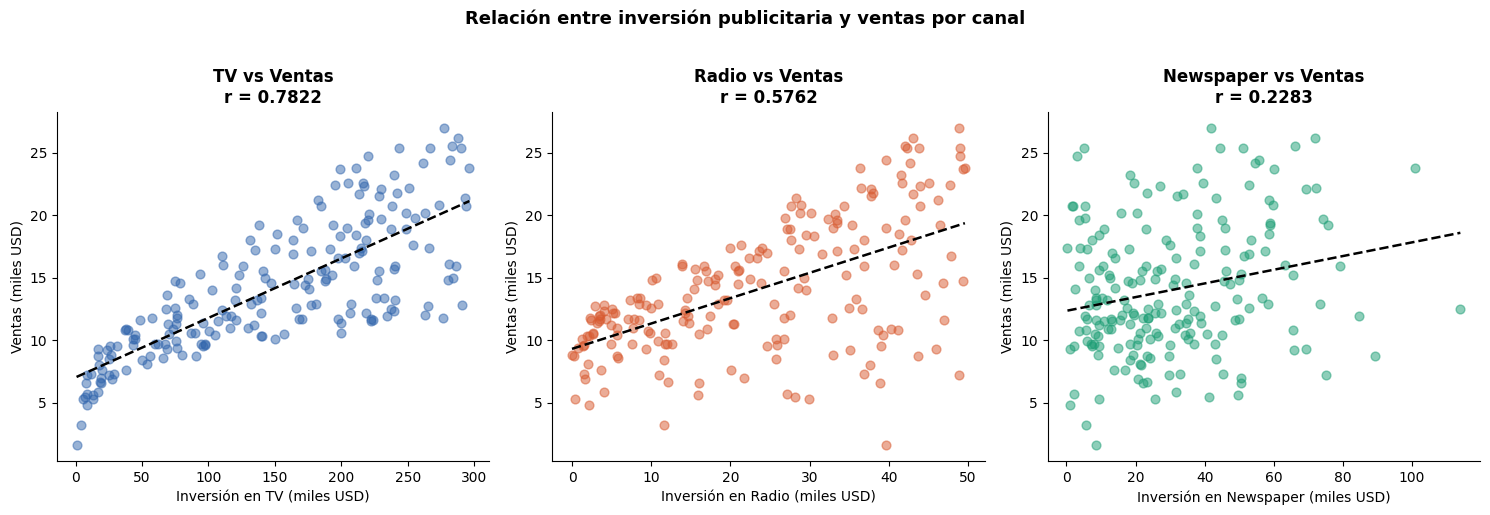

In [30]:
# Correlaciones
corr = df[['TV', 'Radio', 'Newspaper', 'Sales']].corr()['Sales'].drop('Sales')

print('CORRELACIÓN DE PEARSON CON VENTAS')
print('='*45)
for canal, r in corr.items():
    nivel = 'ALTA' if abs(r) > 0.6 else ('MEDIA' if abs(r) > 0.3 else 'BAJA/NULA')
    print(f'  {canal:<12} r = {r:>7.4f}  →  Correlación {nivel}')

# Gráfico de dispersión por canal
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
canales = ['TV', 'Radio', 'Newspaper']
colors  = ['#3266AD', '#D85A30', '#1D9E75']

for ax, canal, color in zip(axes, canales, colors):
    ax.scatter(df[canal], df['Sales'], alpha=0.5, color=color, s=40)
    # Línea de tendencia
    m, b, r, p, se = stats.linregress(df[canal], df['Sales'])
    x_line = np.linspace(df[canal].min(), df[canal].max(), 100)
    ax.plot(x_line, m*x_line + b, color='black', linewidth=1.8, linestyle='--')
    ax.set_title(f'{canal} vs Ventas\nr = {r:.4f}', fontweight='bold', fontsize=12)
    ax.set_xlabel(f'Inversión en {canal} (miles USD)', fontsize=10)
    ax.set_ylabel('Ventas (miles USD)', fontsize=10)

plt.suptitle('Relación entre inversión publicitaria y ventas por canal', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

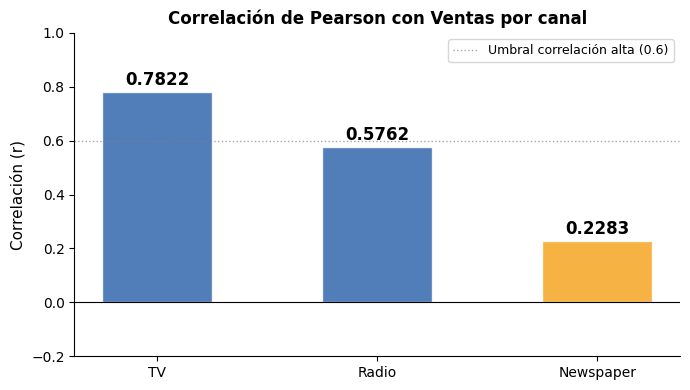

In [31]:
# Gráfico de barras de correlación
fig, ax = plt.subplots(figsize=(7, 4))
corr_vals = corr.values
bar_colors = ['#3266AD' if v > 0.5 else '#F5A623' if v > 0 else '#D85A30' for v in corr_vals]

bars = ax.bar(corr.index, corr_vals, color=bar_colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, corr_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01 if val > 0 else bar.get_height() - 0.04,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.6, color='gray', linewidth=1, linestyle=':', alpha=0.7, label='Umbral correlación alta (0.6)')
ax.set_title('Correlación de Pearson con Ventas por canal', fontweight='bold', fontsize=12)
ax.set_ylabel('Correlación (r)', fontsize=11)
ax.set_ylim(-0.2, 1.0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. FMP por canal — ¿Cómo se distribuye la inversión?

Analizamos la distribución de inversión en cada canal para entender el comportamiento de la campaña.

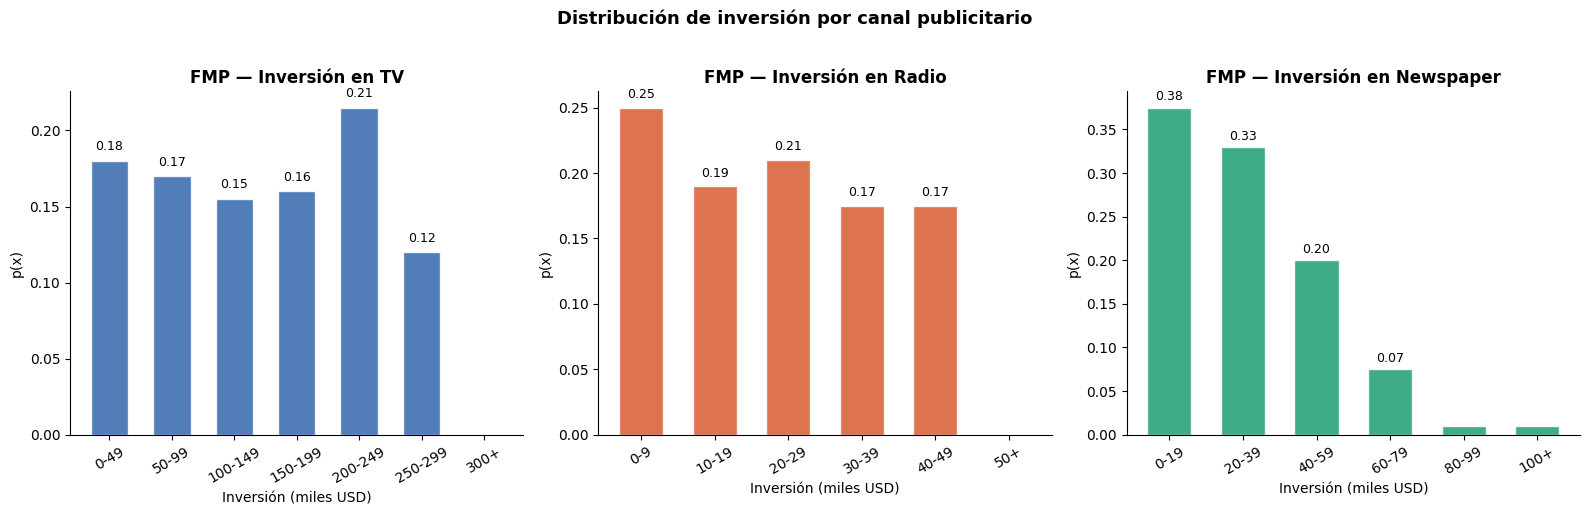

In [32]:
# FMP por canal de inversión
canales_config = {
    'TV':        {'bins': [0,50,100,150,200,250,300,350], 'labels': ['0-49','50-99','100-149','150-199','200-249','250-299','300+'], 'color': '#3266AD'},
    'Radio':     {'bins': [0,10,20,30,40,50,60],          'labels': ['0-9','10-19','20-29','30-39','40-49','50+'],                  'color': '#D85A30'},
    'Newspaper': {'bins': [0,20,40,60,80,100,120],        'labels': ['0-19','20-39','40-59','60-79','80-99','100+'],                'color': '#1D9E75'},
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (canal, cfg) in zip(axes, canales_config.items()):
    col_rango = pd.cut(df[canal], bins=cfg['bins'], labels=cfg['labels'], right=False)
    freq_c    = col_rango.value_counts(sort=False)
    px_c      = freq_c / n

    bars = ax.bar(cfg['labels'], px_c.values, color=cfg['color'], alpha=0.85, edgecolor='white', width=0.6)
    for bar, val in zip(bars, px_c.values):
        if val > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'FMP — Inversión en {canal}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Inversión (miles USD)', fontsize=10)
    ax.set_ylabel('p(x)', fontsize=10)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de inversión por canal publicitario', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Conclusiones del análisis

### Resumen de resultados

In [33]:
print('=' * 60)
print('CONCLUSIONES DEL ANÁLISIS — Problema 33')
print('=' * 60)
print()
print('1. MEDIDAS ESTADÍSTICAS DE VENTAS:')
print(f'   E[X] = μ  = {mu:.2f} miles USD  (valor esperado)')
print(f'   V(X) = σ² = {var:.2f}')
print(f'   σ         = {sigma:.2f} miles USD  (desvío estándar)')
print()
print('2. PROBABILIDADES CLAVE:')
print(f'   P(X ≥ 20)          = {p_al_menos_20:.4f} → {p_al_menos_20*100:.1f}% de mercados con ventas altas')
print(f'   P(X < 10)          = {p_menos_10:.4f} → {p_menos_10*100:.1f}% de mercados con ventas bajas')
print(f'   P(10 ≤ X ≤ 19,9)   = {p_medio:.4f} → {p_medio*100:.1f}% en rango medio')
print(f'   P(X ≥ 25)          = {p_alto:.4f}  → {p_alto*100:.1f}% de mercados élite')
print()
print('3. EFECTIVIDAD POR CANAL:')
for canal, r in corr.items():
    efectivo = '✓ EFECTIVO' if abs(r) > 0.5 else '✗ SIN IMPACTO SIGNIFICATIVO'
    print(f'   {canal:<12} r = {r:>6.4f}  →  {efectivo}')
print()
print('4. RECOMENDACIÓN:')
print('   TV y Radio generan alta correlación con ventas (r ≈ 0.69).')
print('   Newspaper no muestra impacto relevante (r ≈ -0.03).')
print('   Se recomienda reasignar el presupuesto de Newspaper')
print('   hacia TV y Radio para maximizar el retorno de inversión.')
print()

CONCLUSIONES DEL ANÁLISIS — Problema 33

1. MEDIDAS ESTADÍSTICAS DE VENTAS:
   E[X] = μ  = 14.15 miles USD  (valor esperado)
   V(X) = σ² = 29.03
   σ         = 5.39 miles USD  (desvío estándar)

2. PROBABILIDADES CLAVE:
   P(X ≥ 20)          = 0.1550 → 15.5% de mercados con ventas altas
   P(X < 10)          = 0.2250 → 22.5% de mercados con ventas bajas
   P(10 ≤ X ≤ 19,9)   = 0.6200 → 62.0% en rango medio
   P(X ≥ 25)          = 0.0300  → 3.0% de mercados élite

3. EFECTIVIDAD POR CANAL:
   TV           r = 0.7822  →  ✓ EFECTIVO
   Radio        r = 0.5762  →  ✓ EFECTIVO
   Newspaper    r = 0.2283  →  ✗ SIN IMPACTO SIGNIFICATIVO

4. RECOMENDACIÓN:
   TV y Radio generan alta correlación con ventas (r ≈ 0.69).
   Newspaper no muestra impacto relevante (r ≈ -0.03).
   Se recomienda reasignar el presupuesto de Newspaper
   hacia TV y Radio para maximizar el retorno de inversión.

